In [1]:
import torch
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [2]:
datasets_list = ['pems03_flow', 'pems04_flow', 'pems07_flow', 'pems08_flow', 'occpairs_occupancy', 'occhamburg_occupancy', 'pemsbay_speed', 'metrla_speed', 'trafficsh_speed', 'bikenyc_inflow', 'taxinyc_inflow', 'tdrive_inflow']
folder_path = "/data/weichen/ST-Library/datasets/eval_datasets"

In [11]:
for dataset in datasets_list:
    with open(f"{folder_path}/{dataset}/{dataset}_temporal.pkl", "rb") as file:
        df_temporal = pickle.load(file)
        raw_temporal_data = torch.tensor(df_temporal.values).unsqueeze(-1)
        file.close()
    print(f"{dataset}: {df_temporal.shape}")
        
    T, N, _ = raw_temporal_data.shape
    
    # Add time-based features if specified
    feature_list = [raw_temporal_data]
    
    # add_time_of_day
    time_ind = (df_temporal.index.values - df_temporal.index.values.astype('datetime64[D]')) / np.timedelta64(1, 'D')
    time_of_day = np.tile(time_ind, [1, N, 1]).transpose((2, 1, 0))
    feature_list.append(torch.tensor(time_of_day, dtype=torch.float32))
    
    # add_day_of_week:
    dow = df_temporal.index.dayofweek
    dow_tiled = np.tile(dow, [1, N, 1]).transpose((2, 1, 0))
    day_of_week = dow_tiled / 7
    feature_list.append(torch.tensor(day_of_week, dtype=torch.float32))
    
    temporal_data = torch.cat(feature_list, dim=-1).numpy()  # Concatenate features along the channel dimension
    
    output_file_path = f"{folder_path}/../new/{dataset}/{dataset}.npz"  # 定义输出文件路径
    np.savez(output_file_path, data=temporal_data)  # 保存数组，数组名为 'data'

pems03_flow: (26208, 358)
pems04_flow: (16992, 307)
pems07_flow: (28224, 883)
pems08_flow: (17856, 170)
occpairs_occupancy: (96410, 106)
occhamburg_occupancy: (30085, 240)
pemsbay_speed: (52116, 325)
metrla_speed: (34272, 207)
trafficsh_speed: (8413, 896)
bikenyc_inflow: (17275, 200)
taxinyc_inflow: (17275, 200)
tdrive_inflow: (35125, 896)


In [9]:
import numpy as np
from scipy.spatial.distance import cdist


def haversine_np(lon1, lat1, lon2, lat2):
    """向量化Haversine距离计算"""
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c

def thresholded_gaussian_kernel(distance_matrix, r=0.5, sigma=None):
    """
    阈值高斯核实现
    
    参数：
    distance_matrix : np.ndarray [N x N]
        节点间距离矩阵
    r : float
        相似度阈值 (0~1), 默认0.5
    sigma : float, optional
        自定义标准差，默认自动计算
    
    返回：
    adjacency_matrix : np.ndarray [N x N]
        邻接矩阵（带阈值的高斯核）
    """
    # 有效距离过滤（排除对角线和无效值）
    valid_distances = distance_matrix[~np.eye(distance_matrix.shape[0], dtype=bool) & (distance_matrix > 0)]
    
    # 自动计算sigma（全局距离标准差）
    if sigma is None:
        sigma = np.std(valid_distances)
        print(f"Automatically computed sigma: {sigma:.2f} km")
    
    # 高斯核计算
    kernel_matrix = np.exp(-(distance_matrix ** 2) / (sigma ** 2))
    
    # 应用阈值
    mask = (kernel_matrix >= r) & (~np.eye(distance_matrix.shape[0], dtype=bool))
    adjacency_matrix = np.where(mask, kernel_matrix, 0)
    
    # 显式设置对角线为0（即使i=j时计算结果满足条件）
    np.fill_diagonal(adjacency_matrix, 0)
    
    # 确保对称性
    adjacency_matrix = np.maximum(adjacency_matrix, adjacency_matrix.T)
    
    return adjacency_matrix.astype(np.float32)

def generate_graph_adjacency(df_spatial, r=0.5, sigma=None):
    """
    基于经纬度生成邻接矩阵
    
    参数：
    df_spatial : DataFrame
        包含传感器ID、纬度、经度的数据框
    r : float
        相似度阈值 (默认0.5)
    sigma : float, optional
        自定义标准差（默认自动计算）
    
    返回：
    adj_matrix : np.ndarray [N x N]
        阈值高斯核邻接矩阵
    distance_matrix : np.ndarray [N x N]
        原始距离矩阵（单位：千米）
    """
    # 坐标提取
    coords = df_spatial[['Longitude', 'Latitude']].values
    
    # 计算全距离矩阵
    distance_matrix = cdist(coords, coords, lambda u, v: haversine_np(u[0], u[1], v[0], v[1]))
    
    # 生成阈值高斯核矩阵
    adj_matrix = thresholded_gaussian_kernel(distance_matrix, r=r, sigma=sigma)
    
    return adj_matrix

def generate_raster_adjacency(df_spatial):
    """
    基于网格坐标生成一阶邻接矩阵 (八邻域)
    
    参数：
    df_spatial : DataFrame
        包含传感器ID、经度、纬度的数据框, 假设经纬度为网格整数坐标
    
    返回：
    adj_matrix : np.ndarray [N x N]
        邻接矩阵, 1表示相邻, 0表示不相邻
    distance_matrix : np.ndarray [N x N]
        欧式距离矩阵（基于网格坐标）
    """
    # 提取经纬度坐标
    lons = df_spatial['Longitude'].values
    lats = df_spatial['Latitude'].values
    
    # 计算坐标差矩阵
    dx = np.abs(lons[:, None] - lons)
    dy = np.abs(lats[:, None] - lats)
    
    # 生成邻接条件：dx和dy均<=1且不同时为0
    adj_matrix = (dx <= 1) & (dy <= 1) & ((dx + dy) > 0)
    
    # 转换为浮点型并确保对称性
    adj_matrix = adj_matrix.astype(np.float32)
    
    return adj_matrix


for dataset in datasets_list:
    with open(f"{folder_path}/{dataset}/{dataset}_spatial.pkl", "rb") as file:
        df_spatial = pickle.load(file)
        if dataset == 'trafficsh_speed' or dataset == 'bikenyc_inflow' or dataset == 'taxinyc_inflow' or dataset == 'tdrive_inflow':
            adj = generate_raster_adjacency(df_spatial)
        else:
            adj = generate_graph_adjacency(df_spatial)
        file.close()
    print(f"{dataset}: {adj.shape}")
    # 创建目录
    import os
    os.makedirs(f"{folder_path}/../new/{dataset}", exist_ok=True)
    # 保存数据为npy文件
    np.save(f"{folder_path}/../new/{dataset}/{dataset}_rn_adj.npy", adj)

Automatically computed sigma: 10.55 km
pems03_flow: (358, 358)
Automatically computed sigma: 36.19 km
pems04_flow: (307, 307)
Automatically computed sigma: 22.12 km
pems07_flow: (883, 883)
Automatically computed sigma: 18.93 km
pems08_flow: (170, 170)
Automatically computed sigma: 1.08 km
occpairs_occupancy: (106, 106)
Automatically computed sigma: 1.15 km
occhamburg_occupancy: (240, 240)
Automatically computed sigma: 5.36 km
pemsbay_speed: (325, 325)
Automatically computed sigma: 6.94 km
metrla_speed: (207, 207)
trafficsh_speed: (896, 896)
bikenyc_inflow: (200, 200)
taxinyc_inflow: (200, 200)
tdrive_inflow: (896, 896)


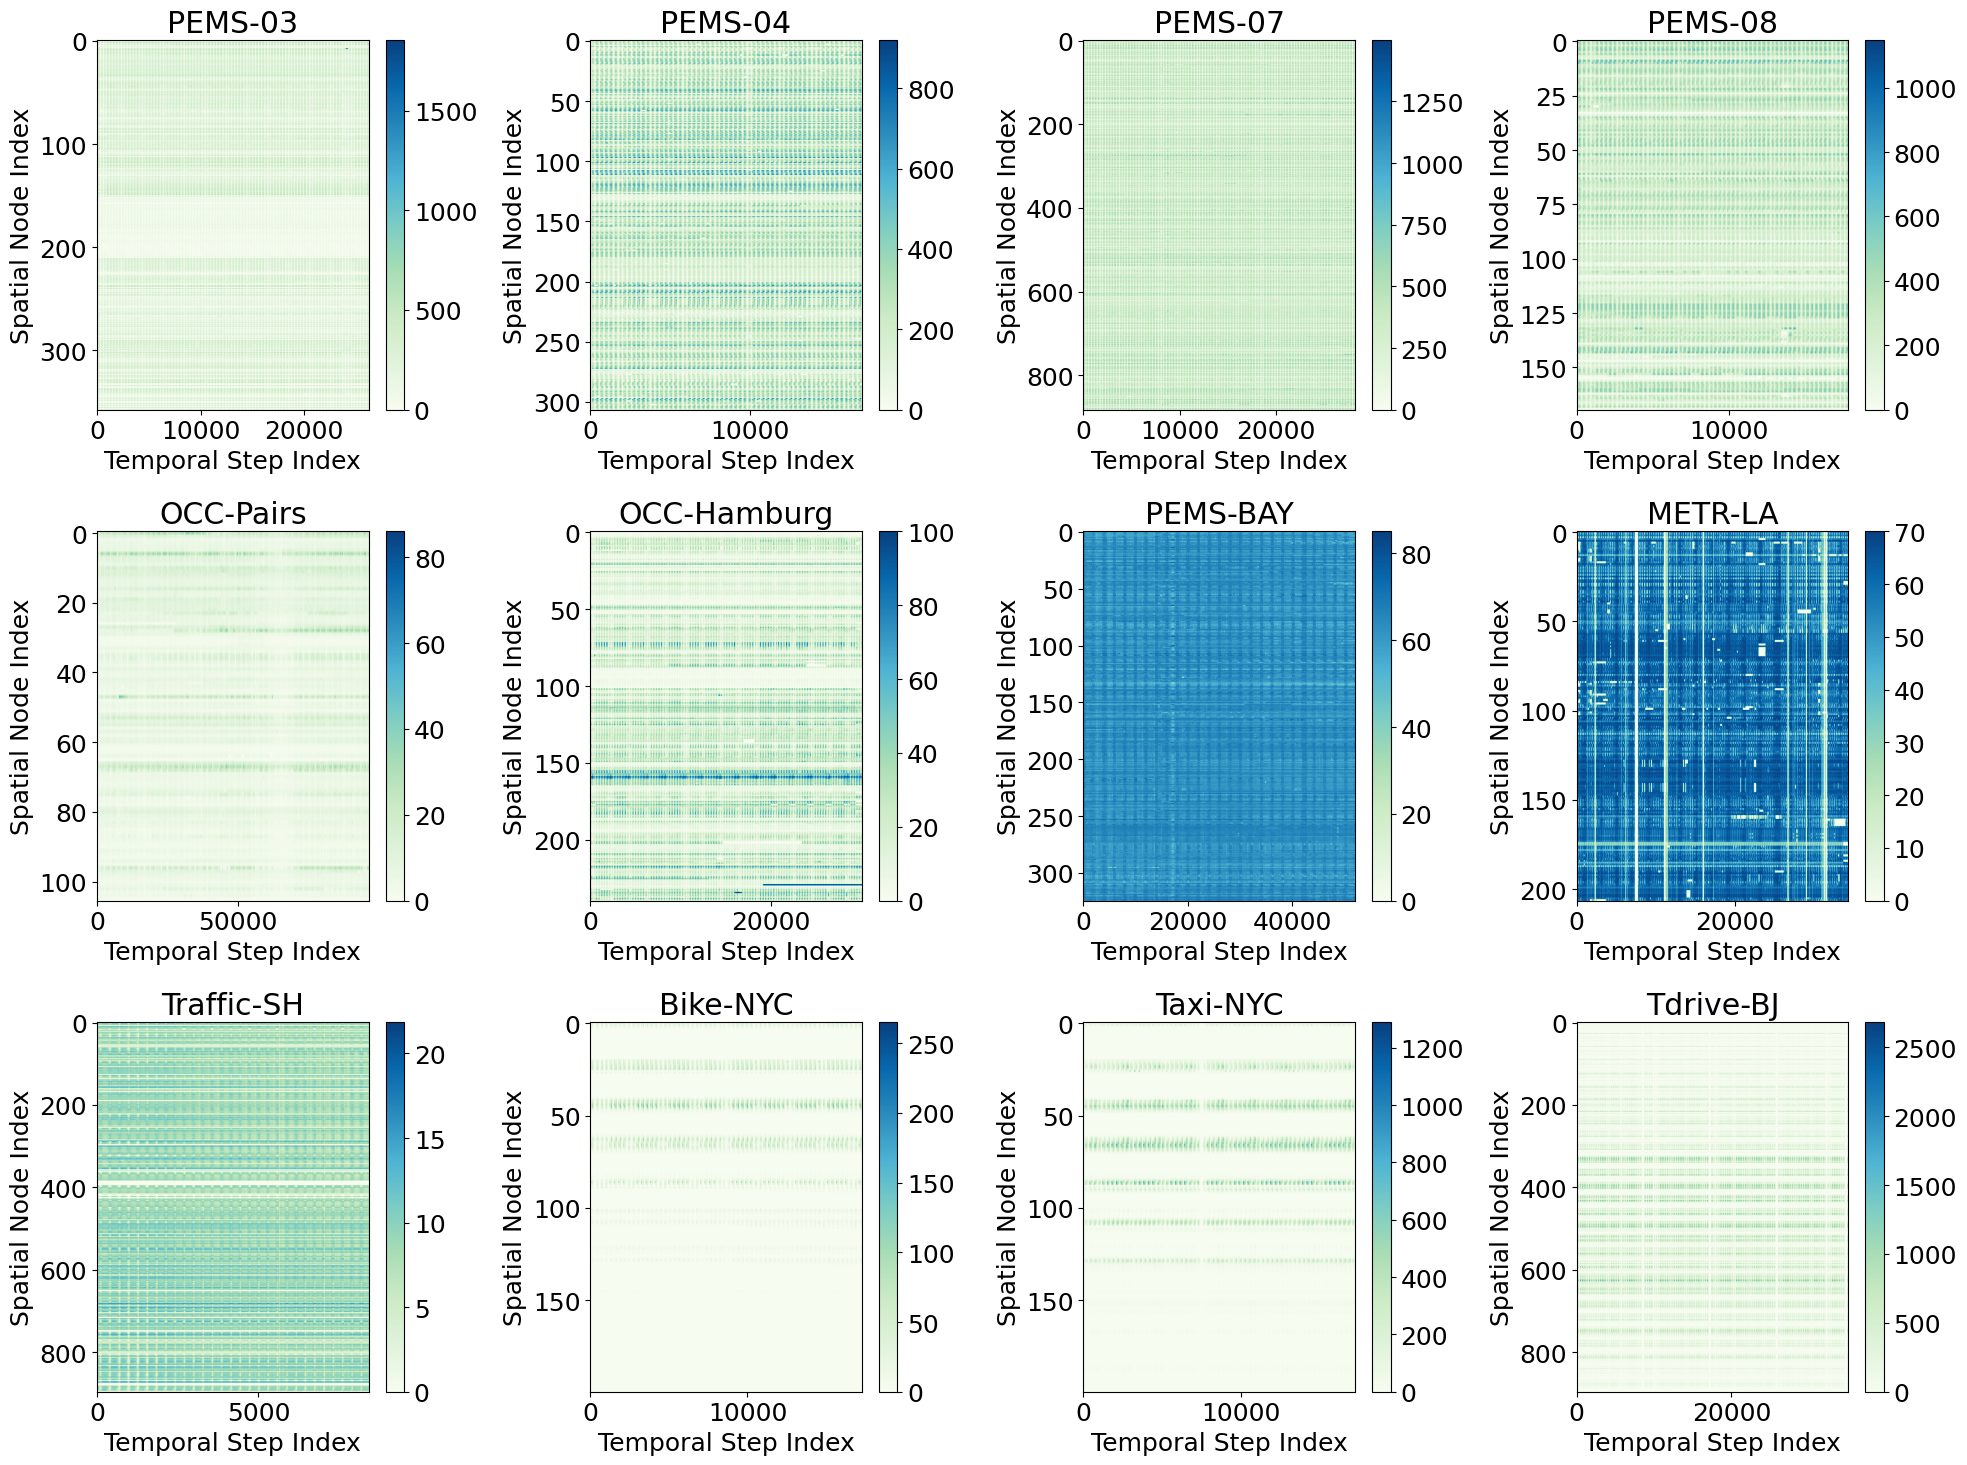

In [30]:
# 设置字体大小
plt.rcParams.update({'font.size': 18})

# 创建一个3*4的子图布局
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

paper_benchmark_name = ["PEMS-03", "PEMS-04", "PEMS-07", "PEMS-08", "OCC-Pairs", "OCC-Hamburg", "PEMS-BAY", "METR-LA", "Traffic-SH", "Bike-NYC", "Taxi-NYC", "Tdrive-BJ"]

for i, dataset in enumerate(datasets_list):
    with open(f"{folder_path}/{dataset}/{dataset}_temporal.pkl", "rb") as file:
        df_temporal = pickle.load(file)
    
    # 将DataFrame转换为numpy数组
    df_temporal_array = df_temporal.to_numpy()
    
    # 获取当前子图
    ax = axes[i//4, i%4]
    
    # 绘制图像，这里以每个时间步为x轴，空间节点数为y轴，值为颜色映射
    im = ax.imshow(    df_temporal_array = df_temporal.to_numpy()
.T, cmap='GnBu', aspect='auto')
    
    # 设置标题
    ax.set_title(f'{paper_benchmark_name[i]}')
    
    # 设置坐标轴标签
    ax.set_xlabel('Temporal Step Index')
    ax.set_ylabel('Spatial Node Index')
    
    # 添加颜色条
    fig.colorbar(im, ax=ax)

# 调整子图间距
plt.tight_layout()

# 保存为PDF文件
plt.savefig('benchmark_st_vis.pdf', format='pdf', bbox_inches='tight')

# 显示图像
plt.show()

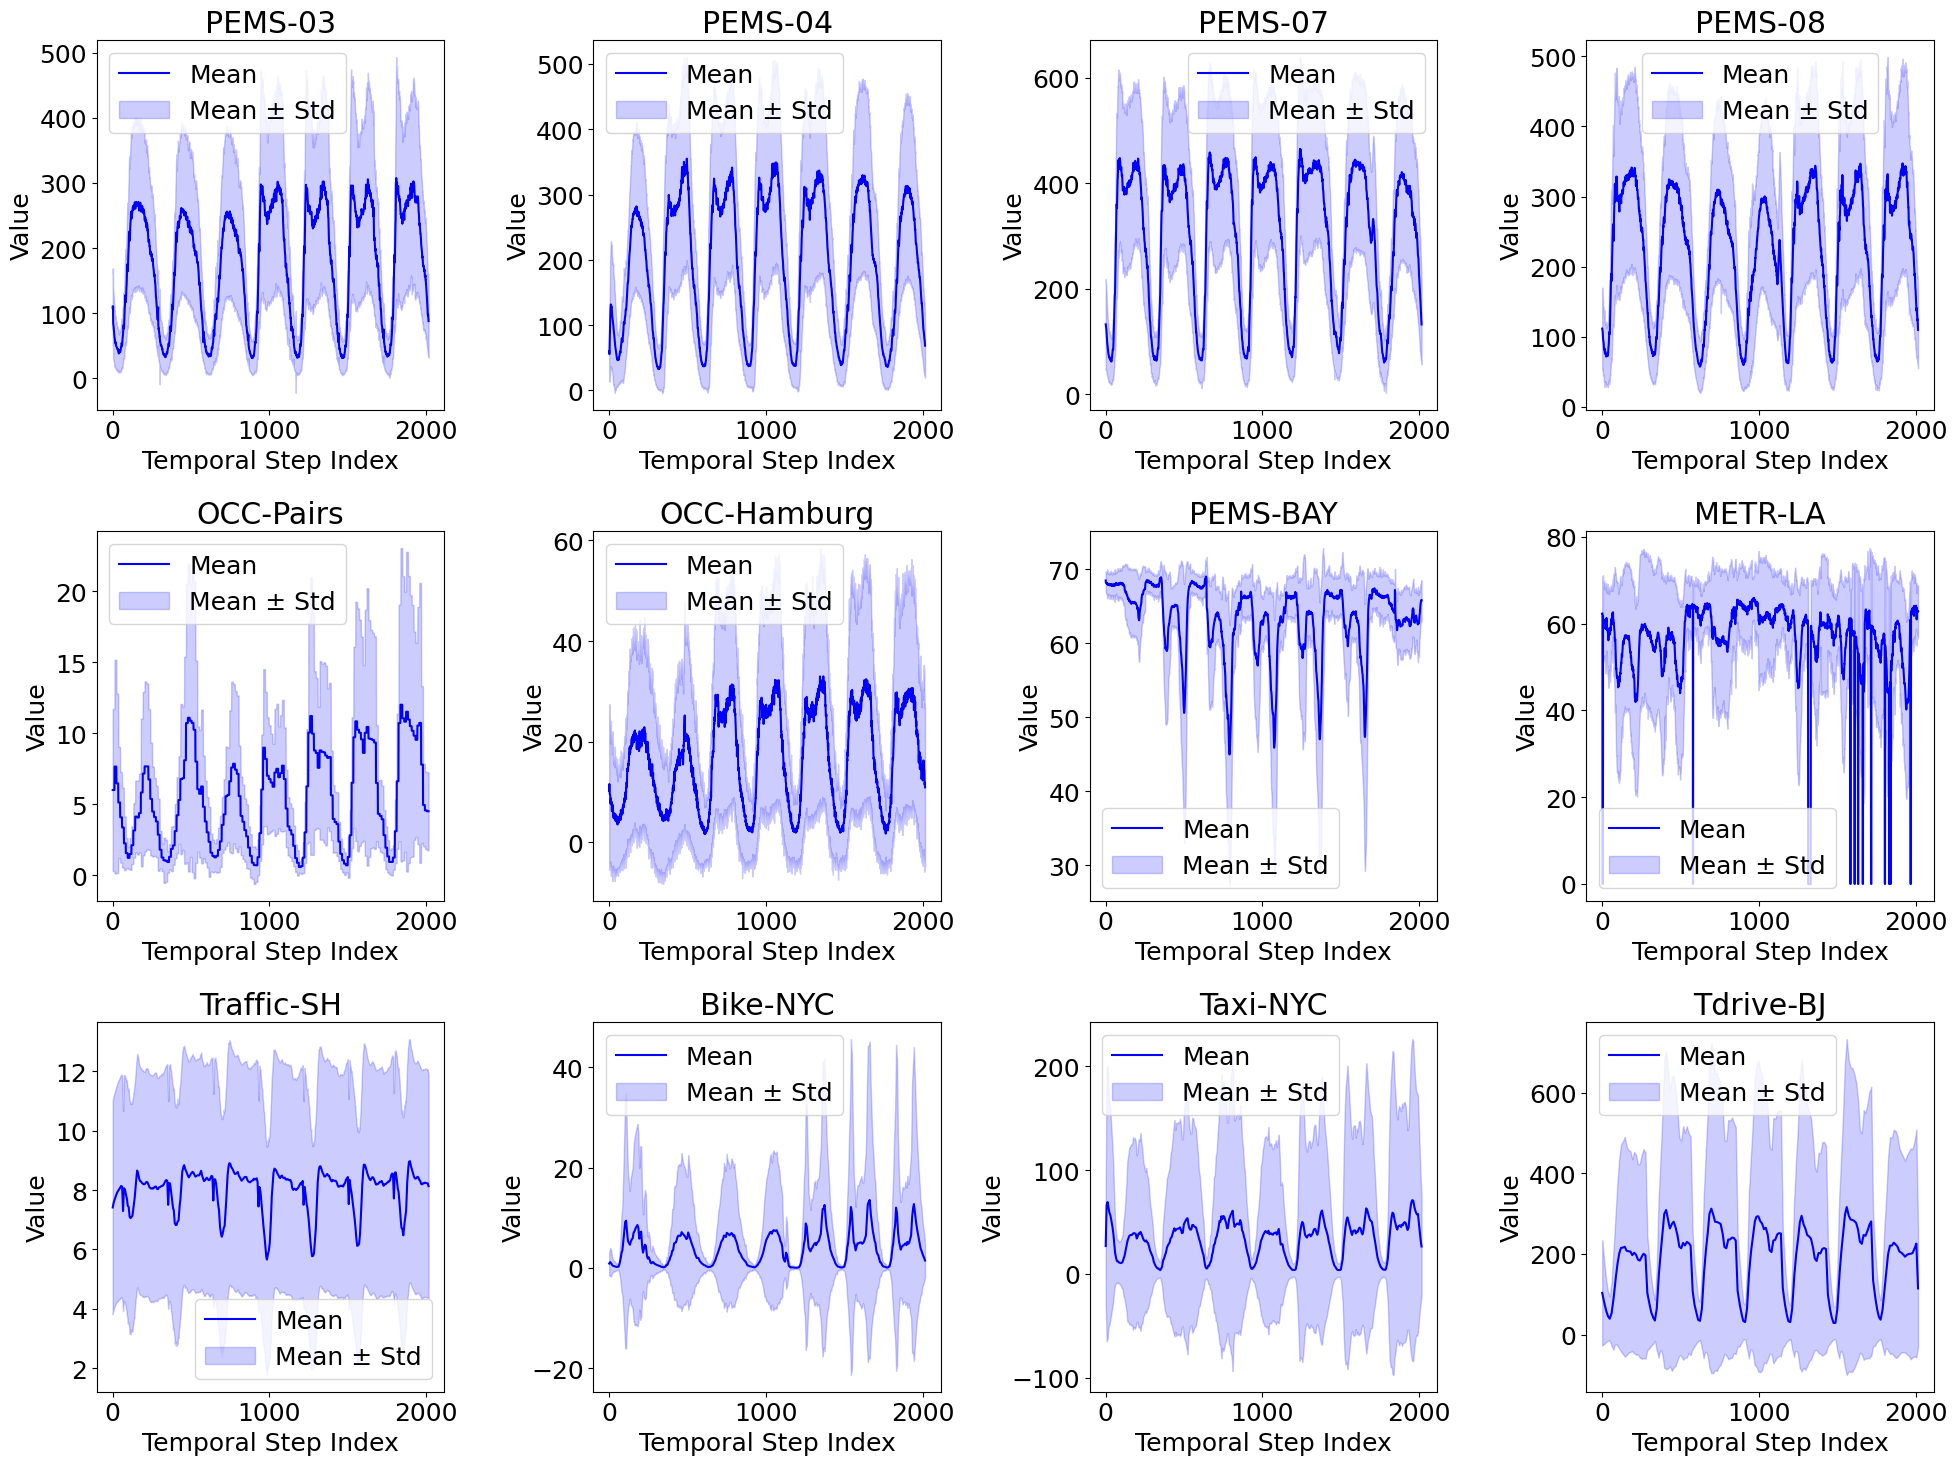

In [31]:
# 创建一个3*4的子图布局
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

paper_benchmark_name = ["PEMS-03", "PEMS-04", "PEMS-07", "PEMS-08", "OCC-Pairs", "OCC-Hamburg", "PEMS-BAY", "METR-LA", "Traffic-SH", "Bike-NYC", "Taxi-NYC", "Tdrive-BJ"]

for i, dataset in enumerate(datasets_list):
    with open(f"{folder_path}/{dataset}/{dataset}_temporal.pkl", "rb") as file:
        df_temporal = pickle.load(file)
    
    # 将DataFrame转换为numpy数组
    df_temporal_array = df_temporal.to_numpy()[:288 * 7]

    # 计算时间序列的均值和标准差
    temporal_mean = np.mean(df_temporal_array, axis=1)
    temporal_std = np.std(df_temporal_array, axis=1)

    # 获取当前子图
    ax = axes[i//4, i%4]

    # 绘制均值和标准差曲线
    x = np.arange(len(temporal_mean))
    ax.plot(x, temporal_mean, label='Mean', color='blue')
    ax.fill_between(x, temporal_mean - temporal_std, temporal_mean + temporal_std, color='blue', alpha=0.2, label='Mean ± Std')

    # 设置标题
    ax.set_title(f'{paper_benchmark_name[i]}')

    # 设置坐标轴标签
    ax.set_xlabel('Temporal Step Index')
    ax.set_ylabel('Value')

    # 添加图例
    ax.legend()

# 调整子图间距
plt.tight_layout()

# 保存为PDF文件
plt.savefig('benchmark_t_vis.pdf', format='pdf', bbox_inches='tight')

# 显示图像
plt.show()

In [5]:
import pickle
folder_path = "/data/weichen/ST-Library/datasets/eval_datasets"

dataset_name = "bikenyc_inflow" # taxinyc_inflow, pemsbay_speed, pems03_flow

with open(f"{folder_path}/{dataset_name}/{dataset_name}_spatial.pkl", "rb") as file:
    df_spatial = pickle.load(file)
df_spatial

,ID,Latitude,Longitude
0,00-00,0,0
1,00-01,0,1
2,00-02,0,2
3,00-03,0,3
4,00-04,0,4
...,...,...,...
195,09-15,9,15
196,09-16,9,16
197,09-17,9,17
198,09-18,9,18


In [40]:
import numpy as np
import pandas as pd
import pickle
from scipy.spatial.distance import cdist

def haversine_np(lon1, lat1, lon2, lat2):
    """向量化Haversine距离计算"""
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c

def thresholded_gaussian_kernel(distance_matrix, r=0.5, sigma=None):
    """
    阈值高斯核实现
    
    参数：
    distance_matrix : np.ndarray [N x N]
        节点间距离矩阵
    r : float
        相似度阈值 (0~1), 默认0.5
    sigma : float, optional
        自定义标准差，默认自动计算
    
    返回：
    adjacency_matrix : np.ndarray [N x N]
        邻接矩阵（带阈值的高斯核）
    """
    # 有效距离过滤（排除对角线和无效值）
    valid_distances = distance_matrix[~np.eye(distance_matrix.shape[0], dtype=bool) & (distance_matrix > 0)]
    
    # 自动计算sigma（全局距离标准差）
    if sigma is None:
        sigma = np.std(valid_distances)
        print(f"Automatically computed sigma: {sigma:.2f} km")
    
    # 高斯核计算
    kernel_matrix = np.exp(-(distance_matrix ** 2) / (sigma ** 2))
    
    # 应用阈值
    mask = (kernel_matrix >= r) & (~np.eye(distance_matrix.shape[0], dtype=bool))
    adjacency_matrix = np.where(mask, kernel_matrix, 0)
    
    # 显式设置对角线为0（即使i=j时计算结果满足条件）
    np.fill_diagonal(adjacency_matrix, 0)
    
    # 确保对称性
    adjacency_matrix = np.maximum(adjacency_matrix, adjacency_matrix.T)
    
    return adjacency_matrix.astype(np.float32)

def generate_adjacency_matrix(df_spatial, r=0.5, sigma=None):
    """
    基于经纬度生成邻接矩阵
    
    参数：
    df_spatial : DataFrame
        包含传感器ID、纬度、经度的数据框
    r : float
        相似度阈值 (默认0.5)
    sigma : float, optional
        自定义标准差（默认自动计算）
    
    返回：
    adj_matrix : np.ndarray [N x N]
        阈值高斯核邻接矩阵
    distance_matrix : np.ndarray [N x N]
        原始距离矩阵（单位：千米）
    """
    # 坐标提取
    coords = df_spatial[['Longitude', 'Latitude']].values
    
    # 计算全距离矩阵
    distance_matrix = cdist(coords, coords, lambda u, v: haversine_np(u[0], u[1], v[0], v[1]))
    
    # 生成阈值高斯核矩阵
    adj_matrix = thresholded_gaussian_kernel(distance_matrix, r=r, sigma=sigma)
    
    return adj_matrix


# 生成矩阵
adj_matrix = generate_adjacency_matrix(df_spatial)

# # 保存结果
# save_path = f"{folder_path}/pems03_flow"
# with open(f"{save_path}/adj_PEMS03_gaussian.pkl", "wb") as f:
#     pickle.dump(adj_matrix, f)
# with open(f"{save_path}/adj_PEMS03_distance.pkl", "wb") as f:
#     pickle.dump(distance_matrix.astype(np.float32), f)

Automatically computed sigma: 473.74 km


In [41]:
adj_matrix

array([[0.        , 0.94639707, 0.80222017, ..., 0.        , 0.        ,
        0.        ],
       [0.94639707, 0.        , 0.94639707, ..., 0.        , 0.        ,
        0.        ],
       [0.80222017, 0.94639707, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.9476739 ,
        0.80655855],
       [0.        , 0.        , 0.        , ..., 0.9476739 , 0.        ,
        0.9476739 ],
       [0.        , 0.        , 0.        , ..., 0.80655855, 0.9476739 ,
        0.        ]], dtype=float32)

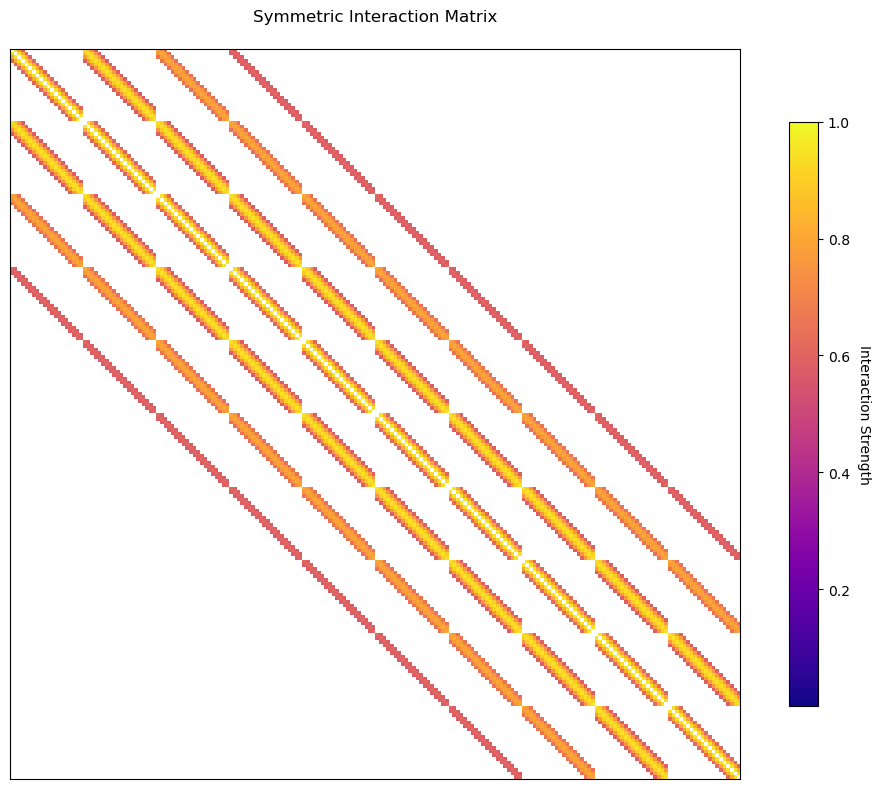

In [42]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8), dpi=100)

# 创建自定义颜色映射
cmap = plt.cm.plasma.copy()
cmap.set_under('white')  # 0值设为纯白
cmap.set_bad('gray')     # 缺失值设为灰色

# 生成热图
heatmap = plt.imshow(
    adj_matrix,
    cmap=cmap,
    aspect='equal',  # 保持方格为正方形
    interpolation='none',  # 禁用插值保持锐利边缘
    vmin=1e-6,       # 最小显示阈值
    vmax=1.0,        # 最大颜色值
    origin='upper'   # 矩阵原点在左上角
)

# 添加颜色条
cbar = plt.colorbar(heatmap, shrink=0.8)
cbar.set_label('Interaction Strength', rotation=270, labelpad=15)

# 优化显示效果
plt.title("Symmetric Interaction Matrix", pad=20)
plt.xticks([])  # 隐藏坐标刻度
plt.yticks([])
plt.tight_layout()
plt.show()

In [44]:
import numpy as np
import pandas as pd
import pickle

def generate_grid_adjacency(df_spatial):
    """
    基于网格坐标生成一阶邻接矩阵 (八邻域)
    
    参数：
    df_spatial : DataFrame
        包含传感器ID、经度、纬度的数据框, 假设经纬度为网格整数坐标
    
    返回：
    adj_matrix : np.ndarray [N x N]
        邻接矩阵, 1表示相邻, 0表示不相邻
    distance_matrix : np.ndarray [N x N]
        欧式距离矩阵（基于网格坐标）
    """
    # 提取经纬度坐标
    lons = df_spatial['Longitude'].values
    lats = df_spatial['Latitude'].values
    
    # 计算坐标差矩阵
    dx = np.abs(lons[:, None] - lons)
    dy = np.abs(lats[:, None] - lats)
    
    # 生成邻接条件：dx和dy均<=1且不同时为0
    adj_matrix = (dx <= 1) & (dy <= 1) & ((dx + dy) > 0)
    
    # 转换为浮点型并确保对称性
    adj_matrix = adj_matrix.astype(np.float32)
    
    return adj_matrix

# 生成矩阵
adj_matrix = generate_grid_adjacency(df_spatial)
adj_matrix

array([[0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 1.],
       [0., 0., 0., ..., 0., 1., 0.]], dtype=float32)

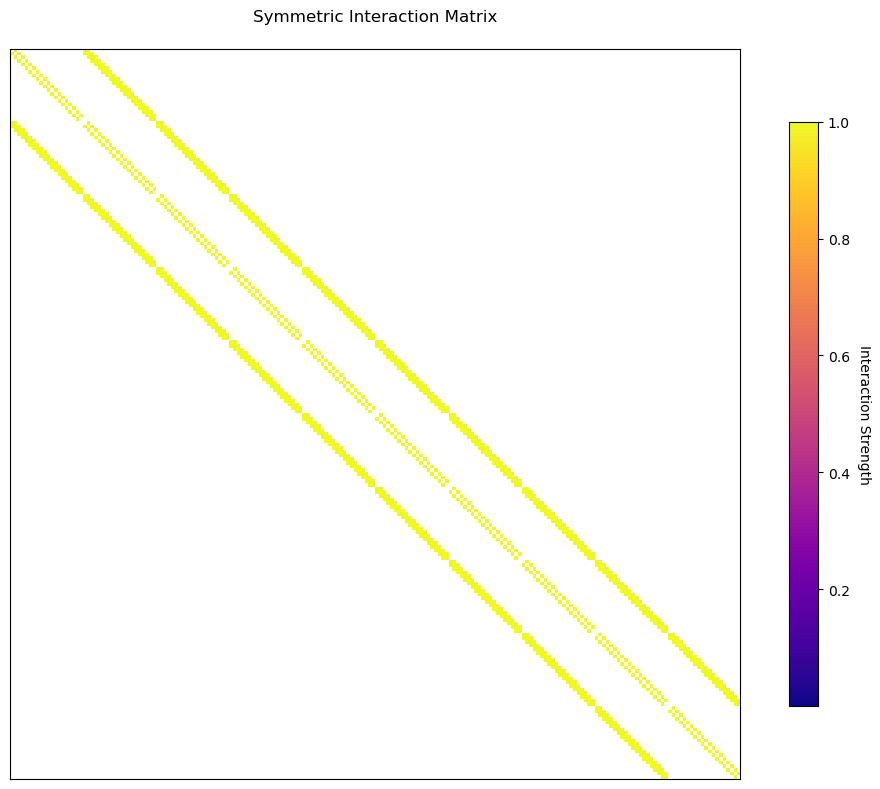

In [45]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8), dpi=100)

# 创建自定义颜色映射
cmap = plt.cm.plasma.copy()
cmap.set_under('white')  # 0值设为纯白
cmap.set_bad('gray')     # 缺失值设为灰色

# 生成热图
heatmap = plt.imshow(
    adj_matrix,
    cmap=cmap,
    aspect='equal',  # 保持方格为正方形
    interpolation='none',  # 禁用插值保持锐利边缘
    vmin=1e-6,       # 最小显示阈值
    vmax=1.0,        # 最大颜色值
    origin='upper'   # 矩阵原点在左上角
)

# 添加颜色条
cbar = plt.colorbar(heatmap, shrink=0.8)
cbar.set_label('Interaction Strength', rotation=270, labelpad=15)

# 优化显示效果
plt.title("Symmetric Interaction Matrix", pad=20)
plt.xticks([])  # 隐藏坐标刻度
plt.yticks([])
plt.tight_layout()
plt.show()